=== ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ===
Загружаем данные...
Загружено 1262 записей
Очищаем данные...
  old_price: заполнено 1081 пропусков
  battery_mah: заполнено 98 пропусков
  rating: заполнено 22 пропусков
  reviews_count: заполнено 22 пропусков
  ram_gb: заполнено 8 пропусков
  storage_gb: заполнено 0 пропусков
  diagonal_in: заполнено 0 пропусков
  num_cameras: заполнено 18 пропусков
  max_camera_mp: заполнено 18 пропусков
Очистка данных завершена
Извлекаем признаки из specs_raw...
Извлечено 4 уникальных значений ядер процессора
Извлечено 2 уникальных значений SIM-карт
Создаем новые признаки...
Создание признаков завершено
Данные загружены и очищены
Размер датасета: (1262, 37)
Финальный размер датасета: (1262, 37)

=== ФИНАЛЬНЫЙ РАСЧЕТ ===
Распределение категорий:
value_category
good_value           317
poor_value           316
average_value        315
great_value          188
exceptional_value    126
Name: count, dtype: int64

Процентное распределение:
value_category
good_value    

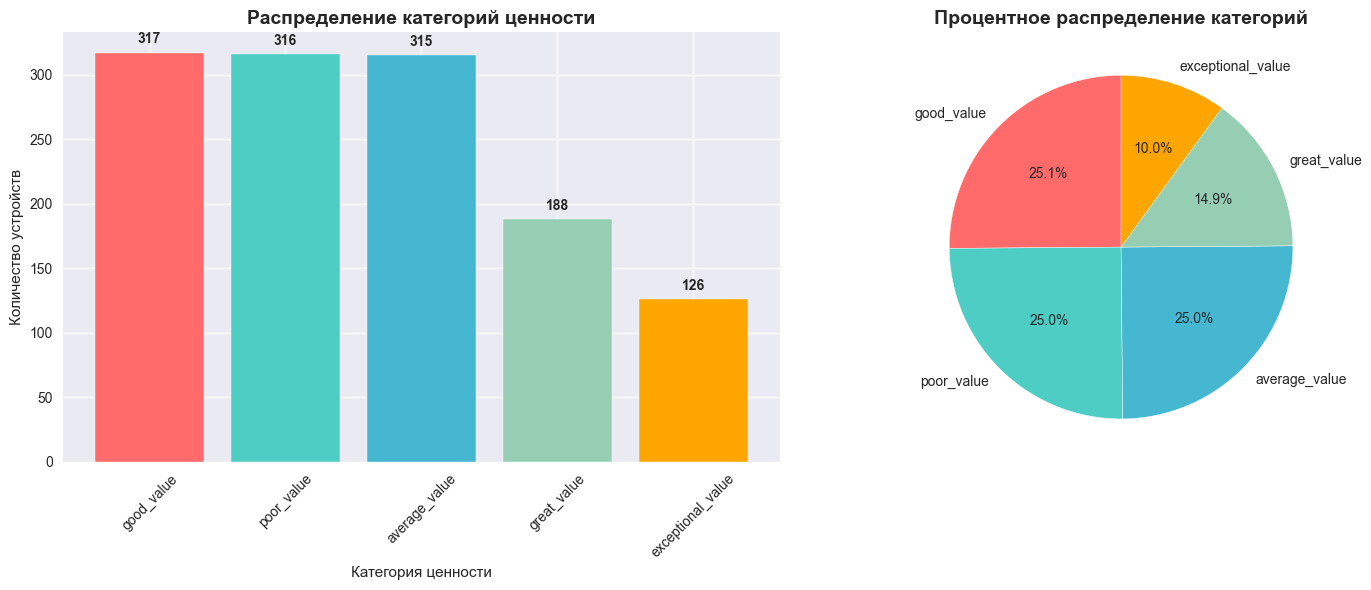


=== ПРОВЕРКА КАТЕГОРИЙ ===

--- POOR_VALUE ---
Apple iPhone 15
  Цена: 64199 руб | RAM: 6.0GB | Память: 128GB
  Камера: 48.0MP | Value Score: 6246.2 | Рейтинг: 4.82

Apple iPhone 13
  Цена: 47999 руб | RAM: 4.0GB | Память: 128GB
  Камера: 12.0MP | Value Score: 4825.2 | Рейтинг: 4.88


--- AVERAGE_VALUE ---
Apple iPhone 16 Pro Max
  Цена: 127399 руб | RAM: 8.0GB | Память: 256GB
  Камера: 48.0MP | Value Score: 8667.6 | Рейтинг: 4.74

Apple iPhone 16 Pro
  Цена: 118799 руб | RAM: 8.0GB | Память: 256GB
  Камера: 48.0MP | Value Score: 8798.0 | Рейтинг: 4.81


--- GOOD_VALUE ---
Xiaomi Redmi Note 14
  Цена: 19699 руб | RAM: 8.0GB | Память: 256GB
  Камера: 108.0MP | Value Score: 12069.7 | Рейтинг: 4.76

Samsung Galaxy S25
  Цена: 70999 руб | RAM: 12.0GB | Память: 256GB
  Камера: 50.0MP | Value Score: 11469.5 | Рейтинг: 4.67


--- GREAT_VALUE ---
Samsung Galaxy S25 Ultra
  Цена: 88999 руб | RAM: 12.0GB | Память: 256GB
  Камера: 200.0MP | Value Score: 14876.0 | Рейтинг: 4.84

POCO X7 Pro
  Цен

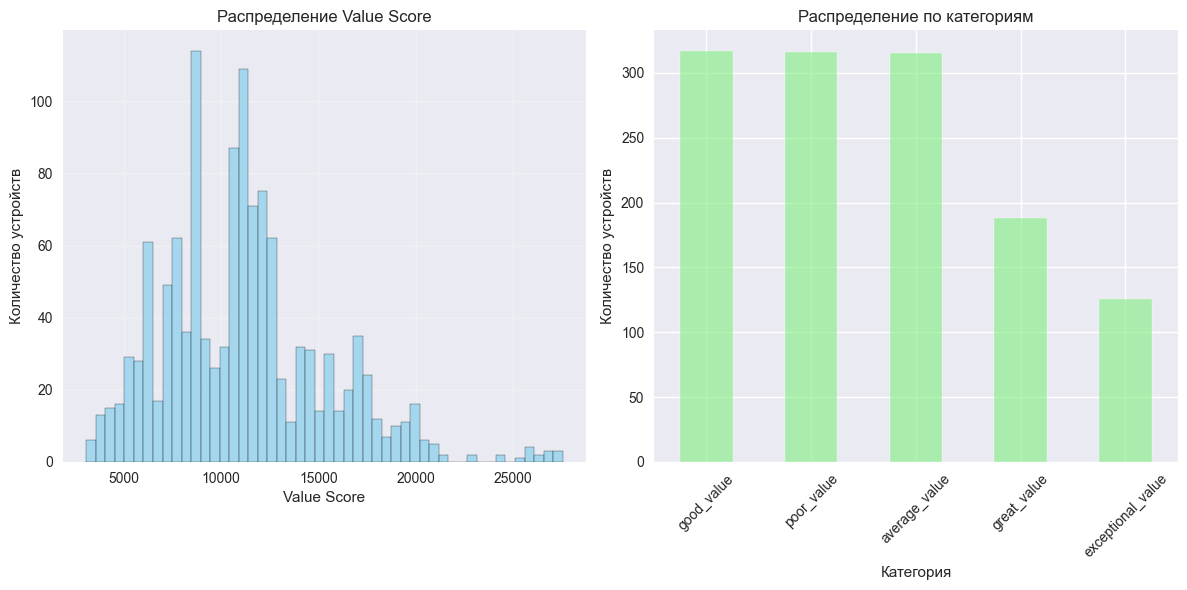


=== СРЕДНИЕ ХАРАКТЕРИСТИКИ ПО КАТЕГОРИЯМ ===


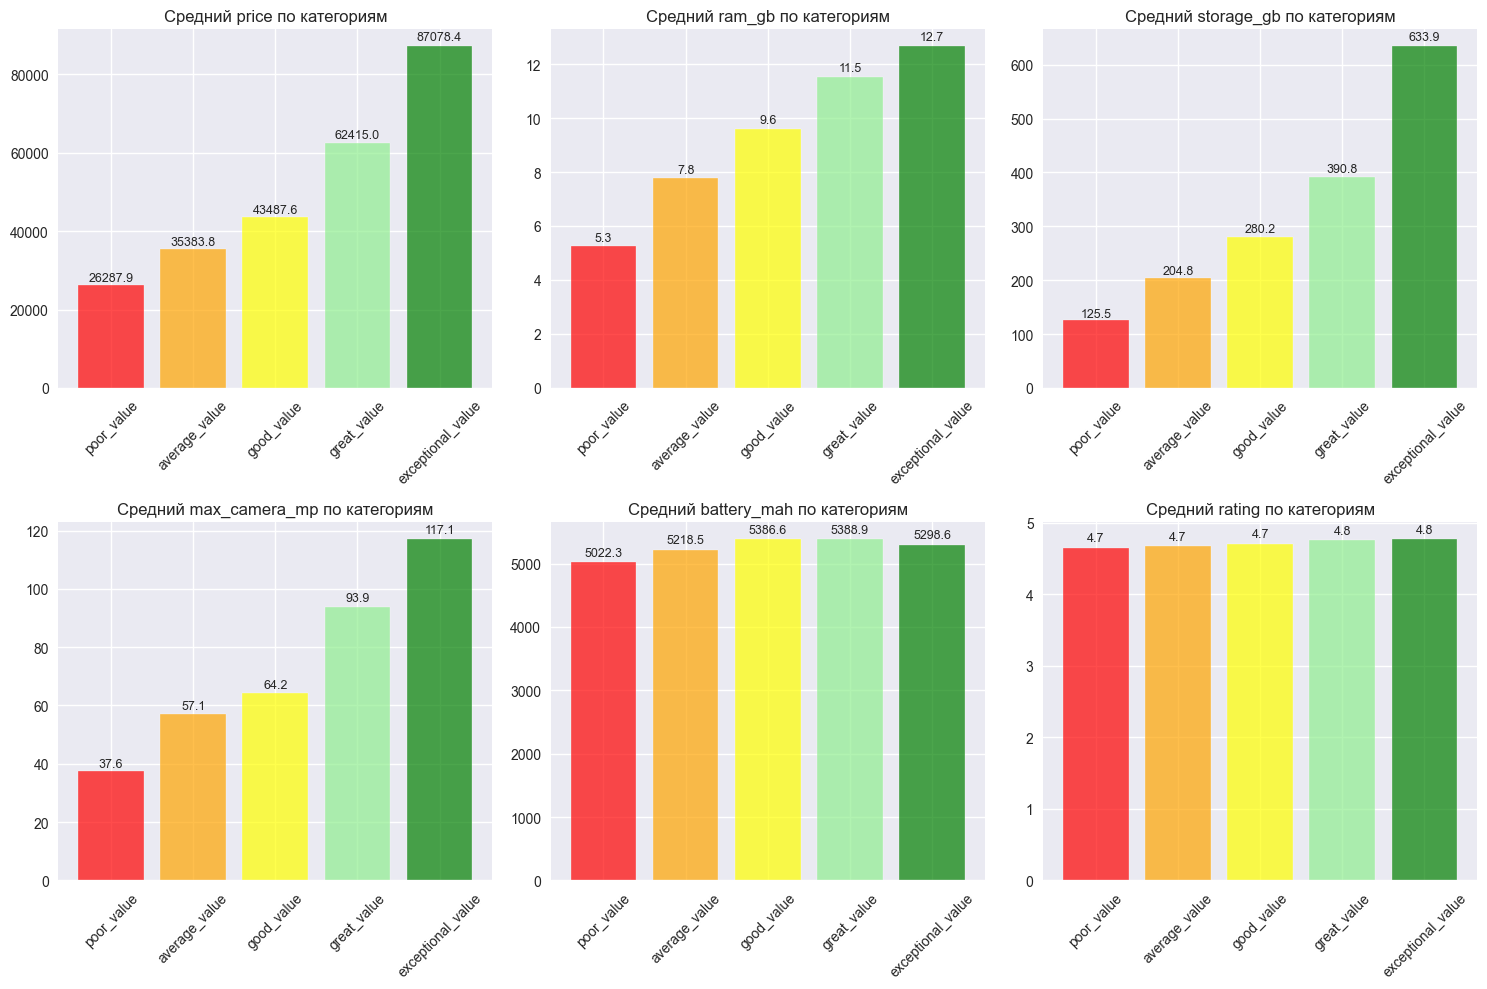


=== КОРРЕЛЯЦИИ ПРИЗНАКОВ С VALUE SCORE ===


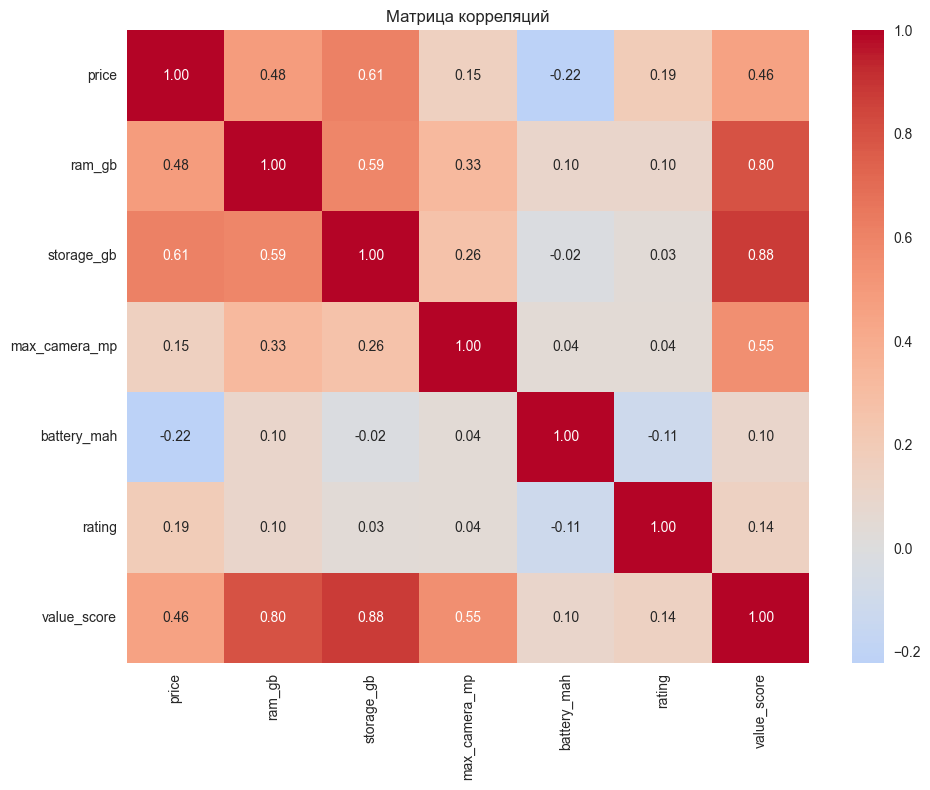

Корреляции с value_score:
  storage_gb: 0.875
  ram_gb: 0.802
  max_camera_mp: 0.549
  price: 0.459
  rating: 0.144
  battery_mah: 0.095


In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

from data_processing import DataProcessor

print("=== ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ===")
processor = DataProcessor()
df = processor.load_data('dataset/dataset.csv')
df_clean = processor.clean_data(df)
df_features = processor.extract_features_from_specs(df_clean)
df_analysis = processor.create_new_features(df_features)

print("Данные загружены и очищены")
print(f"Размер датасета: {df_analysis.shape}")

columns_to_drop = ['value_score', 'value_category', 'value_score_v2', 'value_category_v2',
                   'value_score_v3', 'value_category_v3', 'value_score_final', 'value_category_final']
for col in columns_to_drop:
    if col in df_analysis.columns:
        df_analysis = df_analysis.drop(col, axis=1)
        print(f"Удален столбец: {col}")

print(f"Финальный размер датасета: {df_analysis.shape}")

def calculate_final_value_score(row):
    price = row['price']
    old_price = row.get('old_price', price)
    rating = row.get('rating', 4.0)
    ram = row.get('ram_gb', 4)
    storage = row.get('storage_gb', 64)
    max_camera_mp = row.get('max_camera_mp', 12)
    has_5g = row.get('has_5g', 0)
    battery_mah = row.get('battery_mah', 4000)

    base_features = (
        ram * 8.0 +
        storage * 0.3 +
        battery_mah * 0.0015
    )
    extra_features = (
        max_camera_mp * 0.4 +
        (10 if has_5g else 0)
    )

    total_features = base_features + extra_features
    discount_factor = 1.0
    if old_price > price:
        discount_percent = (old_price - price) / old_price
        discount_factor = 1 + min(discount_percent * 0.15, 0.2)

    rating_factor = 0.6 + (rating - 3) * 0.1 if rating else 0.7
    brand_factor = 1.0
    if row.get('brand') == 'Apple':
        brand_factor = 0.9
    price_factor = np.log(max(price, 10000))
    value_score = (total_features * discount_factor * rating_factor * brand_factor * 800) / price_factor
    return value_score

def create_balanced_categories(value_scores):
    p25 = value_scores.quantile(0.25)
    p50 = value_scores.quantile(0.50)
    p75 = value_scores.quantile(0.75)
    p90 = value_scores.quantile(0.90)
    categories = ['poor_value', 'average_value', 'good_value', 'great_value', 'exceptional_value']
    return pd.cut(value_scores, bins=[-np.inf, p25, p50, p75, p90, np.inf],
                  labels=categories, include_lowest=True)

print("\n=== ФИНАЛЬНЫЙ РАСЧЕТ ===")
df_analysis['value_score'] = df_analysis.apply(calculate_final_value_score, axis=1)
df_analysis['value_category'] = create_balanced_categories(df_analysis['value_score'])
print("Распределение категорий:")
print(df_analysis['value_category'].value_counts())
print("\nПроцентное распределение:")
print(df_analysis['value_category'].value_counts(normalize=True).round(3) * 100)
print("\n=== СТАТИСТИКА VALUE SCORE ===")
print(f"Минимум: {df_analysis['value_score'].min():.1f}")
print(f"Максимум: {df_analysis['value_score'].max():.1f}")
print(f"Среднее: {df_analysis['value_score'].mean():.1f}")
print(f"Медиана: {df_analysis['value_score'].median():.1f}")
correlation = df_analysis['value_score'].corr(df_analysis['price'])
print(f"\nКорреляция с ценой: {correlation:.3f}")

print("\n=== ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ КАТЕГОРИЙ ЦЕННОСТИ ===")
category_counts = df_analysis['value_category'].value_counts()
category_df = pd.DataFrame({
    'Категория': category_counts.index,
    'Количество': category_counts.values
})

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
bars = plt.bar(category_df['Категория'], category_df['Количество'],
               color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#ffa500'])
plt.title('Распределение категорий ценности', fontsize=14, fontweight='bold')
plt.xlabel('Категория ценности')
plt.ylabel('Количество устройств')
plt.xticks(rotation=45)

for bar, count in zip(bars, category_df['Количество']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontweight='bold')

plt.subplot(1, 2, 2)
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#ffa500']
plt.pie(category_df['Количество'], labels=category_df['Категория'], autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Процентное распределение категорий', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== ПРОВЕРКА КАТЕГОРИЙ ===")
for category in ['poor_value', 'average_value', 'good_value', 'great_value', 'exceptional_value']:
    print(f"\n--- {category.upper()} ---")
    examples = df_analysis[df_analysis['value_category'] == category][[
        'brand', 'model', 'price', 'ram_gb', 'storage_gb', 'max_camera_mp', 'value_score', 'rating'
    ]].head(2)

    for idx, row in examples.iterrows():
        print(f"{row['brand']} {row['model']}")
        print(f"  Цена: {row['price']} руб | RAM: {row['ram_gb']}GB | Память: {row['storage_gb']}GB")
        print(f"  Камера: {row['max_camera_mp']}MP | Value Score: {row['value_score']:.1f} | Рейтинг: {row['rating']}\n")

print("\n" + "="*60)
print("=== ПОЛНЫЙ АНАЛИЗ ДАННЫХ ===")
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(df_analysis['value_score'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Распределение Value Score')
plt.xlabel('Value Score')
plt.ylabel('Количество устройств')
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
df_analysis['value_category'].value_counts().plot(kind='bar', color='lightgreen', alpha=0.7)
plt.title('Распределение по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество устройств')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n=== СРЕДНИЕ ХАРАКТЕРИСТИКИ ПО КАТЕГОРИЯМ ===")
plt.figure(figsize=(15, 10))
features_to_check = ['price', 'ram_gb', 'storage_gb', 'max_camera_mp', 'battery_mah', 'rating']

for i, feature in enumerate(features_to_check, 1):
    plt.subplot(2, 3, i)
    avg_by_category = df_analysis.groupby('value_category')[feature].mean()

    category_order = ['poor_value', 'average_value', 'good_value', 'great_value', 'exceptional_value']
    avg_by_category = avg_by_category.reindex(category_order)
    colors = ['red', 'orange', 'yellow', 'lightgreen', 'green']
    bars = plt.bar(avg_by_category.index, avg_by_category.values, color=colors, alpha=0.7)
    plt.title(f'Средний {feature} по категориям')
    plt.xticks(rotation=45)

    for bar, v in zip(bars, avg_by_category.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (v * 0.01),
                f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== КОРРЕЛЯЦИИ ПРИЗНАКОВ С VALUE SCORE ===")
numeric_columns = ['price', 'ram_gb', 'storage_gb', 'max_camera_mp', 'battery_mah', 'rating', 'value_score']
correlation_matrix = df_analysis[numeric_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

print("Корреляции с value_score:")
value_score_correlations = correlation_matrix['value_score'].sort_values(ascending=False)
for feature, corr in value_score_correlations.items():
    if feature != 'value_score':
        print(f"  {feature}: {corr:.3f}")

### Baseline

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
%matplotlib inline
print("Библиотеки загружены")

Библиотеки загружены


In [3]:
print("=== ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ===")
from data_processing import DataProcessor

processor = DataProcessor()
df = processor.load_data('dataset/dataset.csv')
df_clean = processor.clean_data(df)
df_features = processor.extract_features_from_specs(df_clean)
df_final = processor.create_new_features(df_features)

print(f"Исходный размер: {df.shape}")
print(f"После очистки: {df_final.shape}")

columns_to_drop = ['value_score', 'value_category']
for col in columns_to_drop:
    if col in df_final.columns:
        df_final = df_final.drop(col, axis=1)
        print(f"Удален столбец: {col}")

print(f"Финальный размер: {df_final.shape}")

=== ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ===
Загружаем данные...
Загружено 1262 записей
Очищаем данные...
  old_price: заполнено 1081 пропусков
  battery_mah: заполнено 98 пропусков
  rating: заполнено 22 пропусков
  reviews_count: заполнено 22 пропусков
  ram_gb: заполнено 8 пропусков
  storage_gb: заполнено 0 пропусков
  diagonal_in: заполнено 0 пропусков
  num_cameras: заполнено 18 пропусков
  max_camera_mp: заполнено 18 пропусков
Очистка данных завершена
Извлекаем признаки из specs_raw...
Извлечено 4 уникальных значений ядер процессора
Извлечено 2 уникальных значений SIM-карт
Создаем новые признаки...
Создание признаков завершено
Исходный размер: (1262, 29)
После очистки: (1262, 37)
Финальный размер: (1262, 37)


In [4]:
print("=== СОЗДАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===")

def calculate_value_score(row):
    price = row['price']
    old_price = row.get('old_price', price)
    rating = row.get('rating', 4.0)
    ram = row.get('ram_gb', 4)
    storage = row.get('storage_gb', 64)
    max_camera_mp = row.get('max_camera_mp', 12)
    has_5g = row.get('has_5g', 0)
    battery_mah = row.get('battery_mah', 4000)

    base_features = (
        ram * 8.0 +
        storage * 0.3 +
        battery_mah * 0.0015
    )
    extra_features = (
        max_camera_mp * 0.4 +
        (10 if has_5g else 0)
    )
    total_features = base_features + extra_features
    discount_factor = 1.0
    if old_price > price:
        discount_percent = (old_price - price) / old_price
        discount_factor = 1 + min(discount_percent * 0.15, 0.2)
    rating_factor = 0.6 + (rating - 3) * 0.1 if rating else 0.7
    price_factor = np.log(max(price, 10000))
    value_score = (total_features * discount_factor * rating_factor * 800) / price_factor
    return value_score
df_final['value_score'] = df_final.apply(calculate_value_score, axis=1)

def create_categories(value_scores):
    p25 = value_scores.quantile(0.25)
    p50 = value_scores.quantile(0.50)
    p75 = value_scores.quantile(0.75)
    p90 = value_scores.quantile(0.90)
    categories = ['poor_value', 'average_value', 'good_value', 'great_value', 'exceptional_value']
    return pd.cut(value_scores, bins=[-np.inf, p25, p50, p75, p90, np.inf],
                  labels=categories, include_lowest=True)

df_final['value_category'] = create_categories(df_final['value_score'])
print("Распределение категорий:")
print(df_final['value_category'].value_counts())
print("\nПроцентное распределение:")
print(df_final['value_category'].value_counts(normalize=True).round(3) * 100)

=== СОЗДАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ===
Распределение категорий:
value_category
poor_value           318
good_value           315
average_value        313
great_value          190
exceptional_value    126
Name: count, dtype: int64

Процентное распределение:
value_category
poor_value           25.2
good_value           25.0
average_value        24.8
great_value          15.1
exceptional_value    10.0
Name: proportion, dtype: float64


In [5]:
print("=== ПОДГОТОВКА ДАННЫХ ДЛЯ ML ===")

X, y = processor.prepare_for_training(df_final)
print(f"Признаки (X): {X.shape}")
print(f"Целевая переменная (y): {y.shape}")
print(f"Уникальные классы: {np.unique(y)}")

from training import ModelTrainer
trainer = ModelTrainer(test_size=0.2, val_size=0.2, random_state=42)
X_train, X_val, X_test, y_train, y_val, y_test = trainer.split_data(X, y)
print(f"\nРазделение данных:")
print(f"Обучающая выборка: {X_train.shape[0]} samples")
print(f"Валидационная выборка: {X_val.shape[0]} samples")
print(f"Тестовая выборка: {X_test.shape[0]} samples")
print(f"\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts(normalize=True))

=== ПОДГОТОВКА ДАННЫХ ДЛЯ ML ===
Подготавливаем данные для ML...
Используем 20 числовых признаков
Используем 4 категориальных признаков
Финальный размер признаков: (1262, 24)
Целевая переменная: 5 классов
Признаки (X): (1262, 24)
Целевая переменная (y): (1262,)
Уникальные классы: ['average_value' 'exceptional_value' 'good_value' 'great_value'
 'poor_value']
Разделяем данные на train/validation/test...
Train set: 756 samples
Validation set: 253 samples
Test set: 253 samples

Разделение данных:
Обучающая выборка: 756 samples
Валидационная выборка: 253 samples
Тестовая выборка: 253 samples

Распределение классов в обучающей выборке:
value_category
poor_value           0.251323
good_value           0.250000
average_value        0.247354
great_value          0.150794
exceptional_value    0.100529
Name: proportion, dtype: float64


In [6]:
print("=== ЧЕСТНЫЙ BASELINE, использующий только простые правила на основе признаков ===")

class HonestBaseline:
    def predict(self, X):
        predictions = []
        for _, row in X.iterrows():
            price = row['price']
            ram = row.get('ram_gb', 4)
            storage = row.get('storage_gb', 64)
            camera = row.get('max_camera_mp', 12)
            rating = row.get('rating', 4.0)
            battery = row.get('battery_mah', 4000)
            has_5g = row.get('has_5g', 0)
            features_per_price = (ram * 2 + storage * 0.1 + camera * 0.5 + battery * 0.0002) / (price / 10000)
            bonus_features = (1 if has_5g else 0) * 0.5 + (rating - 3) * 0.2
            total_score = features_per_price + bonus_features
            if total_score > 12:
                pred = 'exceptional_value'
            elif total_score > 8:
                pred = 'great_value'
            elif total_score > 5:
                pred = 'good_value'
            elif total_score > 2.5:
                pred = 'average_value'
            else:
                pred = 'poor_value'

            predictions.append(pred)
        return np.array(predictions)

honest_baseline = HonestBaseline()
y_pred_honest = honest_baseline.predict(X_val)
honest_accuracy = accuracy_score(y_val, y_pred_honest)
print(f"Accuracy честного Baseline: {honest_accuracy:.4f}")
print("\nClassification Report для честного Baseline:")
print(classification_report(y_val, y_pred_honest))
print("\nУникальные предсказанные категории:", np.unique(y_pred_honest))

=== ЧЕСТНЫЙ BASELINE, использующий только простые правила на основе признаков ===
Accuracy честного Baseline: 0.1304

Classification Report для честного Baseline:
                   precision    recall  f1-score   support

    average_value       0.00      0.00      0.00        63
exceptional_value       0.11      0.80      0.19        25
       good_value       0.09      0.03      0.05        63
      great_value       0.27      0.29      0.28        38
       poor_value       0.00      0.00      0.00        64

         accuracy                           0.13       253
        macro avg       0.09      0.22      0.10       253
     weighted avg       0.07      0.13      0.07       253


Уникальные предсказанные категории: ['exceptional_value' 'good_value' 'great_value']


In [7]:
print("=== УЛУЧШЕННЫЙ ЧЕСТНЫЙ BASELINE С ОБУЧЕНИЕМ ===")

class ImprovedHonestBaseline:
    def __init__(self):
        self.price_thresholds = None
        self.feature_weights = None

    def fit(self, X_train, y_train):
        print("Анализируем данные для настройки порогов...")
        train_data = df_final.loc[X_train.index].copy()
        train_data['target'] = y_train
        self.price_thresholds = {}
        for category in train_data['target'].unique():
            category_data = train_data[train_data['target'] == category]
            self.price_thresholds[category] = {
                'min': category_data['price'].quantile(0.25),
                'max': category_data['price'].quantile(0.75),
                'median': category_data['price'].median()
            }
        self.feature_means = train_data.groupby('target').agg({
            'ram_gb': 'mean',
            'storage_gb': 'mean',
            'max_camera_mp': 'mean',
            'battery_mah': 'mean',
            'rating': 'mean'
        }).to_dict()
        print("Анализ завершен. Используем эмпирические правила:")
        for category in sorted(self.price_thresholds.keys()):
            stats = self.price_thresholds[category]
            print(f"  {category}: цена {stats['min']:.0f}-{stats['max']:.0f} руб")
        return self

    def predict(self, X):
        if self.price_thresholds is None:
            raise ValueError("Вызовите fit()")
        predictions = []
        for _, row in X.iterrows():
            price = row['price']
            ram = row.get('ram_gb', 4)
            storage = row.get('storage_gb', 64)
            camera = row.get('max_camera_mp', 12)
            rating = row.get('rating', 4.0)
            battery = row.get('battery_mah', 4000)

            price_score = 0
            for category, thresholds in self.price_thresholds.items():
                if thresholds['min'] <= price <= thresholds['max']:
                    price_score += 2
                elif abs(price - thresholds['median']) / thresholds['median'] < 0.3:
                    price_score += 1
            value_ratio = (ram * 0.3 + storage * 0.1 + camera * 0.2 + battery * 0.0001) / max(price / 10000, 1)
            feature_score = (
                (1 if ram >= 8 else 0) +
                (1 if storage >= 128 else 0) +
                (1 if camera >= 50 else 0) +
                (1 if battery >= 4500 else 0) +
                (1 if rating >= 4.5 else 0)
            )

            total_score = price_score + value_ratio * 10 + feature_score
            if total_score > 15:
                pred = 'exceptional_value'
            elif total_score > 11:
                pred = 'great_value'
            elif total_score > 7:
                pred = 'good_value'
            elif total_score > 4:
                pred = 'average_value'
            else:
                pred = 'poor_value'
            predictions.append(pred)
        return np.array(predictions)

improved_honest = ImprovedHonestBaseline()
improved_honest.fit(X_train, y_train)
y_pred_improved_honest = improved_honest.predict(X_val)
improved_honest_accuracy = accuracy_score(y_val, y_pred_improved_honest)
print(f"Accuracy улучшенного честного Baseline: {improved_honest_accuracy:.4f}")
print("\nClassification Report для улучшенного честного Baseline:")
print(classification_report(y_val, y_pred_improved_honest))

=== УЛУЧШЕННЫЙ ЧЕСТНЫЙ BASELINE С ОБУЧЕНИЕМ ===
Анализируем данные для настройки порогов...
Анализ завершен. Используем эмпирические правила:
  average_value: цена 13899-46499 руб
  exceptional_value: цена 34999-120374 руб
  good_value: цена 17199-45999 руб
  great_value: цена 32799-99999 руб
  poor_value: цена 7499-18999 руб
Accuracy улучшенного честного Baseline: 0.0988

Classification Report для улучшенного честного Baseline:
                   precision    recall  f1-score   support

    average_value       0.00      0.00      0.00        63
exceptional_value       0.10      1.00      0.18        25
       good_value       0.00      0.00      0.00        63
      great_value       0.00      0.00      0.00        38
       poor_value       0.00      0.00      0.00        64

         accuracy                           0.10       253
        macro avg       0.02      0.20      0.04       253
     weighted avg       0.01      0.10      0.02       253



In [8]:
print("=== НАИВНЫЙ BASELINE, предсказывает самый частый класс ===")

class NaiveBaseline:
    def __init__(self):
        self.most_common = None

    def fit(self, X_train, y_train):
        self.most_common = y_train.mode()[0]
        print(f"Самый частый класс: {self.most_common}")
        return self

    def predict(self, X):
        return np.array([self.most_common] * len(X))

naive_baseline = NaiveBaseline()
naive_baseline.fit(X_train, y_train)
y_pred_naive = naive_baseline.predict(X_val)

naive_accuracy = accuracy_score(y_val, y_pred_naive)
print(f"Accuracy наивного Baseline: {naive_accuracy:.4f}")
print("\nClassification Report для наивного Baseline:")
print(classification_report(y_val, y_pred_naive))

=== НАИВНЫЙ BASELINE, предсказывает самый частый класс ===
Самый частый класс: poor_value
Accuracy наивного Baseline: 0.2530

Classification Report для наивного Baseline:
                   precision    recall  f1-score   support

    average_value       0.00      0.00      0.00        63
exceptional_value       0.00      0.00      0.00        25
       good_value       0.00      0.00      0.00        63
      great_value       0.00      0.00      0.00        38
       poor_value       0.25      1.00      0.40        64

         accuracy                           0.25       253
        macro avg       0.05      0.20      0.08       253
     weighted avg       0.06      0.25      0.10       253



=== СРАВНЕНИЕ ВСЕХ BASELINE МОДЕЛЕЙ ===


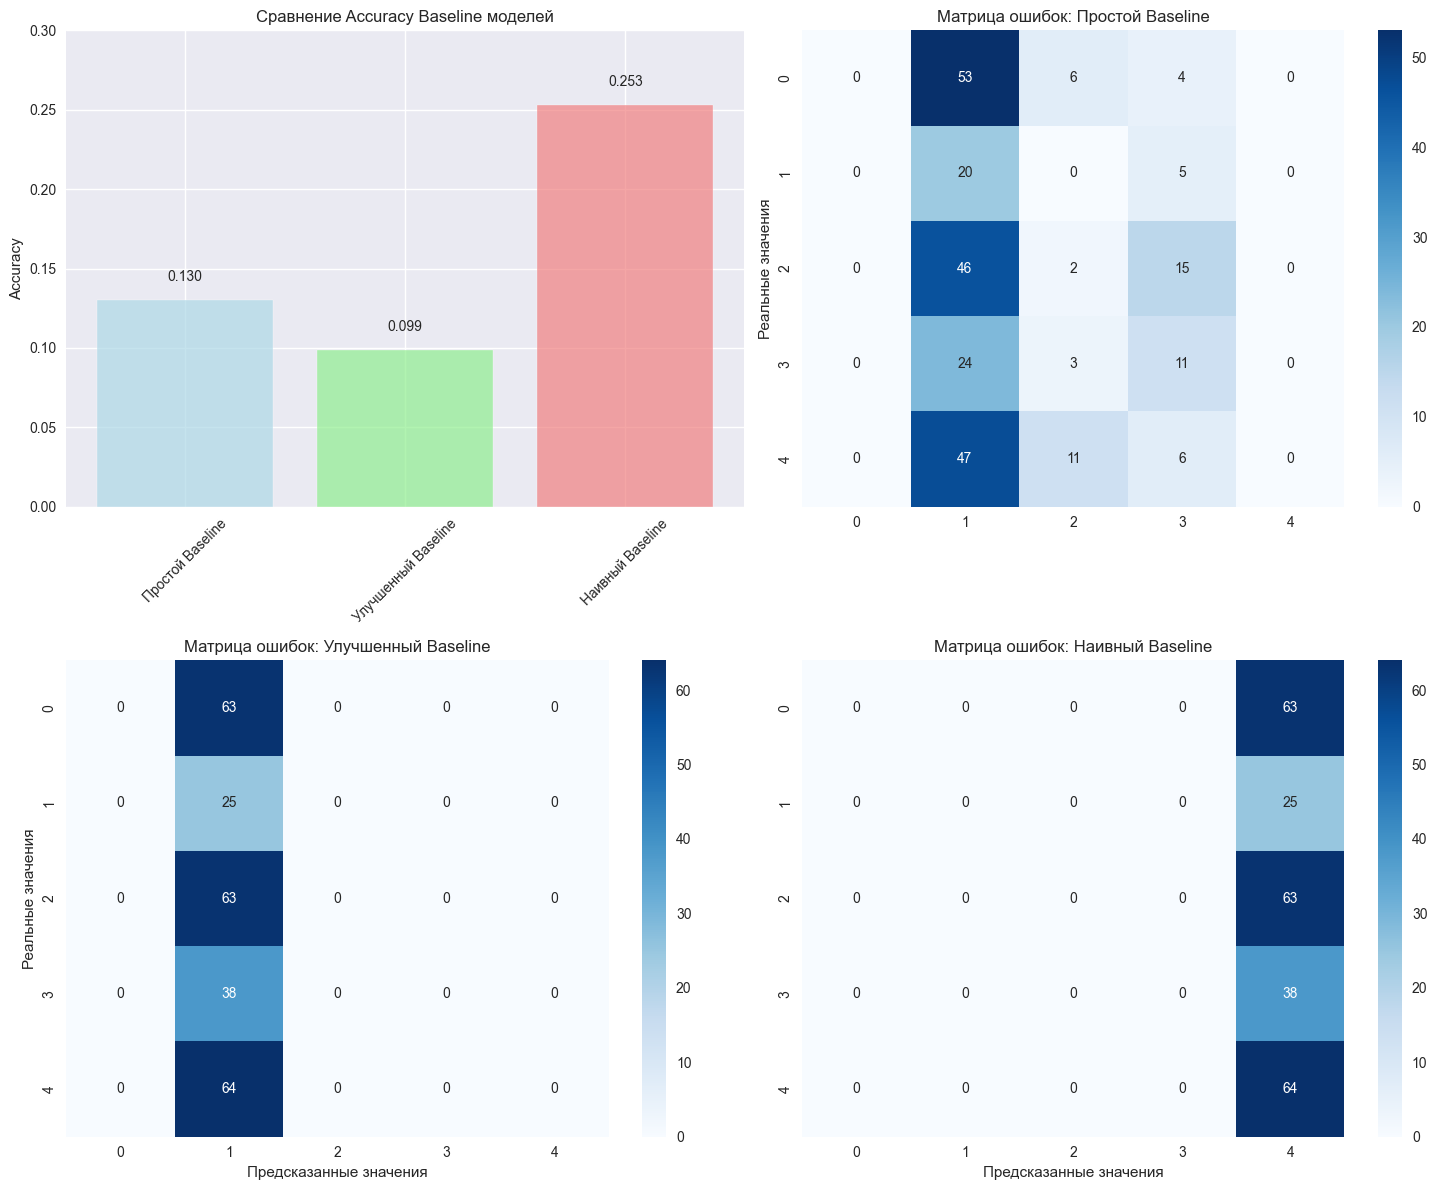

Сводка по всем Baseline моделям:
  Простой Baseline: 0.130
  Улучшенный Baseline: 0.099
  Наивный Baseline: 0.253


In [9]:
print("=== СРАВНЕНИЕ ВСЕХ BASELINE МОДЕЛЕЙ ===")

models_comparison = {
    'Простой Baseline': honest_accuracy,
    'Улучшенный Baseline': improved_honest_accuracy,
    'Наивный Baseline': naive_accuracy
}

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
models_names = list(models_comparison.keys())
accuracies = list(models_comparison.values())
bars = axes[0, 0].bar(models_names, accuracies,
                     color=['lightblue', 'lightgreen', 'lightcoral'],
                     alpha=0.7)
axes[0, 0].set_title('Сравнение Accuracy Baseline моделей')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim(0, 0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{acc:.3f}', ha='center', va='bottom')

cm_simple = confusion_matrix(y_val, y_pred_honest)
sns.heatmap(cm_simple, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('Матрица ошибок: Простой Baseline')
axes[0, 1].set_ylabel('Реальные значения')

cm_improved = confusion_matrix(y_val, y_pred_improved_honest)
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Матрица ошибок: Улучшенный Baseline')
axes[1, 0].set_ylabel('Реальные значения')
axes[1, 0].set_xlabel('Предсказанные значения')

cm_naive = confusion_matrix(y_val, y_pred_naive)
sns.heatmap(cm_naive, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title('Матрица ошибок: Наивный Baseline')
axes[1, 1].set_xlabel('Предсказанные значения')

plt.tight_layout()
plt.show()

print("Сводка по всем Baseline моделям:")
for model_name, accuracy in models_comparison.items():
    print(f"  {model_name}: {accuracy:.3f}")

In [10]:
print("=== СОХРАНЕНИЕ BASELINE ===")
baseline_accuracy = naive_accuracy
baseline_predictions = y_pred_naive
print(f"Baseline установлен:")
print(f"   Модель: Наивный классификатор")
print(f"   Accuracy: {baseline_accuracy:.4f}")
print(f"   Стратегия: Всегда предсказывает '{naive_baseline.most_common}'")

import joblib
baseline_model_info = {
    'model': naive_baseline,
    'accuracy': baseline_accuracy,
    'predictions': baseline_predictions,
    'type': 'naive_baseline'
}
joblib.dump(baseline_model_info, 'baseline_model.pkl')
print("Baseline модель сохранена в 'baseline_model.pkl'")
if 'baseline_accuracy' not in globals():
    baseline_accuracy = naive_accuracy
print(f"Baseline accuracy для сравнения с ML моделями: {baseline_accuracy:.4f}")

=== СОХРАНЕНИЕ BASELINE ===
Baseline установлен:
   Модель: Наивный классификатор
   Accuracy: 0.2530
   Стратегия: Всегда предсказывает 'poor_value'
Baseline модель сохранена в 'baseline_model.pkl'
Baseline accuracy для сравнения с ML моделями: 0.2530


=== ОСНОВНЫЕ МЕТРИКИ ДЛЯ НАИВНОГО BASELINE ===
ОСНОВНЫЕ МЕТРИКИ КЛАССИФИКАЦИИ:
Accuracy:           0.2530
Precision (macro):  0.0506
Recall (macro):     0.2000
F1-Score (macro):   0.0808


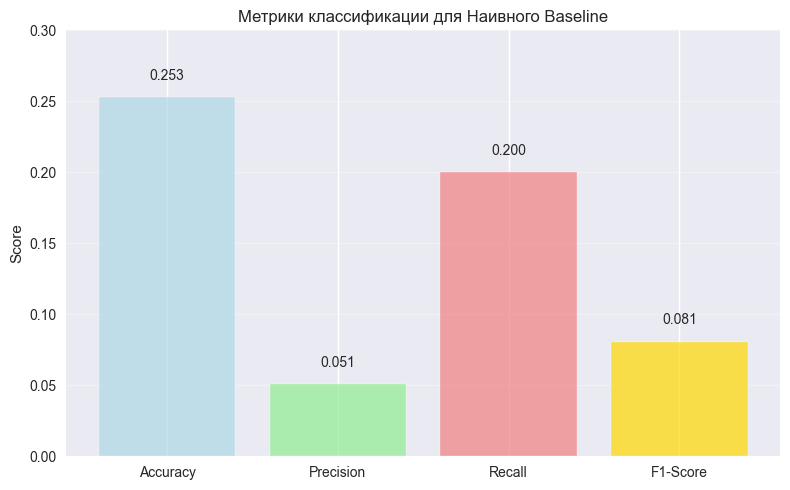


ВЫВОД: Наивный baseline устанавливает реалистичную цель:
ML модели должны показать accuracy > 0.253


In [11]:
print("=== ОСНОВНЫЕ МЕТРИКИ ДЛЯ НАИВНОГО BASELINE ===")

from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_val, y_pred_naive, average='macro', zero_division=0)
recall = recall_score(y_val, y_pred_naive, average='macro', zero_division=0)
f1 = f1_score(y_val, y_pred_naive, average='macro', zero_division=0)
print("ОСНОВНЫЕ МЕТРИКИ КЛАССИФИКАЦИИ:")
print(f"Accuracy:           {naive_accuracy:.4f}")
print(f"Precision (macro):  {precision:.4f}")
print(f"Recall (macro):     {recall:.4f}")
print(f"F1-Score (macro):   {f1:.4f}")
plt.figure(figsize=(8, 5))
metrics = [naive_accuracy, precision, recall, f1]
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['lightblue', 'lightgreen', 'lightcoral', 'gold']
bars = plt.bar(labels, metrics, color=colors, alpha=0.7)
plt.title('Метрики классификации для Наивного Baseline')
plt.ylabel('Score')
plt.ylim(0, 0.3)

for bar, metric in zip(bars, metrics):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{metric:.3f}', ha='center', va='bottom')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print(f"\nВЫВОД: Наивный baseline устанавливает реалистичную цель:")
print(f"ML модели должны показать accuracy > {naive_accuracy:.3f}")

### Обучение Random Forest в sklearn

In [12]:
print("=== ML МОДЕЛЬ: СЛУЧАЙНЫЙ ЛЕС (RANDOM FOREST) ===")
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Обучаем базовую модель Random Forest...")
base_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
base_rf_model.fit(X_train, y_train)
y_train_pred_base = base_rf_model.predict(X_train)
y_val_pred_base = base_rf_model.predict(X_val)
train_accuracy_base = accuracy_score(y_train, y_train_pred_base)
val_accuracy_base = accuracy_score(y_val, y_val_pred_base)

print(f"Accuracy базовой модели:")
print(f"  Обучающая выборка: {train_accuracy_base:.4f}")
print(f"  Валидационная выборка: {val_accuracy_base:.4f}")
print(f"  Baseline accuracy: {baseline_accuracy:.4f}")
overfitting_gap_base = train_accuracy_base - val_accuracy_base
print(f"Разница train/val accuracy: {overfitting_gap_base:.4f}")
if overfitting_gap_base > 0.1:
    print("Возможно сильное переобучение!")
elif overfitting_gap_base > 0.05:
    print("Умеренное переобучение")
else:
    print("Переобучение в норме")
print("\nClassification Report для валидационной выборки:")
print(classification_report(y_val, y_val_pred_base))

=== ML МОДЕЛЬ: СЛУЧАЙНЫЙ ЛЕС (RANDOM FOREST) ===
Обучаем базовую модель Random Forest...
Accuracy базовой модели:
  Обучающая выборка: 1.0000
  Валидационная выборка: 0.9565
  Baseline accuracy: 0.2530
Разница train/val accuracy: 0.0435
Переобучение в норме

Classification Report для валидационной выборки:
                   precision    recall  f1-score   support

    average_value       0.97      0.95      0.96        63
exceptional_value       0.96      0.88      0.92        25
       good_value       0.93      0.98      0.95        63
      great_value       0.92      0.92      0.92        38
       poor_value       1.00      0.98      0.99        64

         accuracy                           0.96       253
        macro avg       0.95      0.94      0.95       253
     weighted avg       0.96      0.96      0.96       253



=== ВАЖНОСТЬ ПРИЗНАКОВ ===


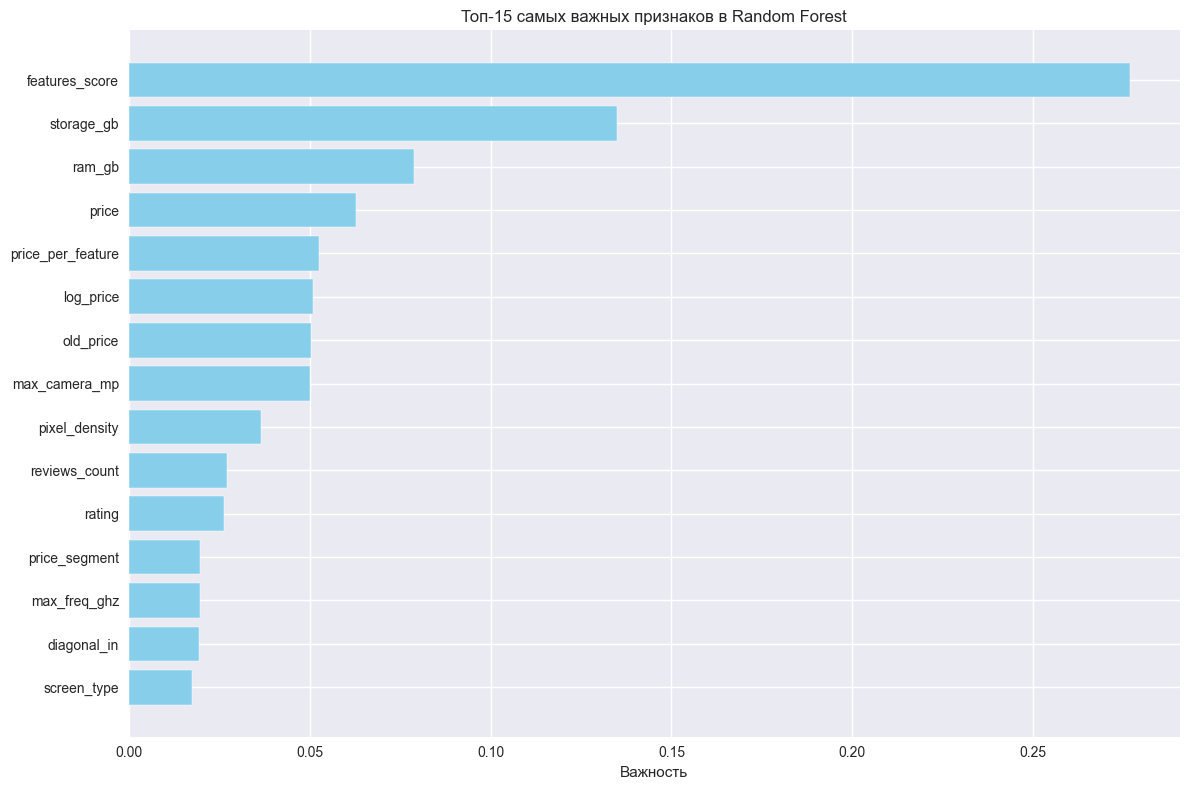

Самые важные признаки:
  reviews_count: 0.0271
  pixel_density: 0.0366
  max_camera_mp: 0.0501
  old_price: 0.0505
  log_price: 0.0509
  price_per_feature: 0.0527
  price: 0.0627
  ram_gb: 0.0789
  storage_gb: 0.1351
  features_score: 0.2767


In [13]:
print("=== ВАЖНОСТЬ ПРИЗНАКОВ ===")
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': base_rf_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance.tail(15)['feature'],
         feature_importance.tail(15)['importance'],
         color='skyblue')
plt.title('Топ-15 самых важных признаков в Random Forest')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

print("Самые важные признаки:")
for i, row in feature_importance.tail(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

In [14]:
print("=== ПОДБОР ГИПЕРПАРАМЕТРОВ (GRID SEARCH) ===")

from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
print("Сетка параметров:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")
rf_for_grid = RandomForestClassifier(random_state=42, n_jobs=-1)
print("\nЗапускаем GridSearch")
grid_search = GridSearchCV(
    estimator=rf_for_grid, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
print("\nПоиск завершен!")
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая accuracy на кросс-валидации: {grid_search.best_score_:.4f}")
best_rf_model = grid_search.best_estimator_

y_train_pred_best = best_rf_model.predict(X_train)
y_val_pred_best = best_rf_model.predict(X_val)
train_accuracy_best = accuracy_score(y_train, y_train_pred_best)
val_accuracy_best = accuracy_score(y_val, y_val_pred_best)
print(f"\nAccuracy лучшей модели:")
print(f"  Обучающая выборка: {train_accuracy_best:.4f}")
print(f"  Валидационная выборка: {val_accuracy_best:.4f}")
improvement = val_accuracy_best - val_accuracy_base
print(f"Улучшение над базовой моделью: {improvement:.4f}")

=== ПОДБОР ГИПЕРПАРАМЕТРОВ (GRID SEARCH) ===
Сетка параметров:
  n_estimators: [50, 100, 200]
  max_depth: [10, 20, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2']

Запускаем GridSearch
Fitting 3 folds for each of 162 candidates, totalling 486 fits

Поиск завершен!
Лучшие параметры: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Лучшая accuracy на кросс-валидации: 0.9365

Accuracy лучшей модели:
  Обучающая выборка: 1.0000
  Валидационная выборка: 0.9565
Улучшение над базовой моделью: 0.0000


=== СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ===


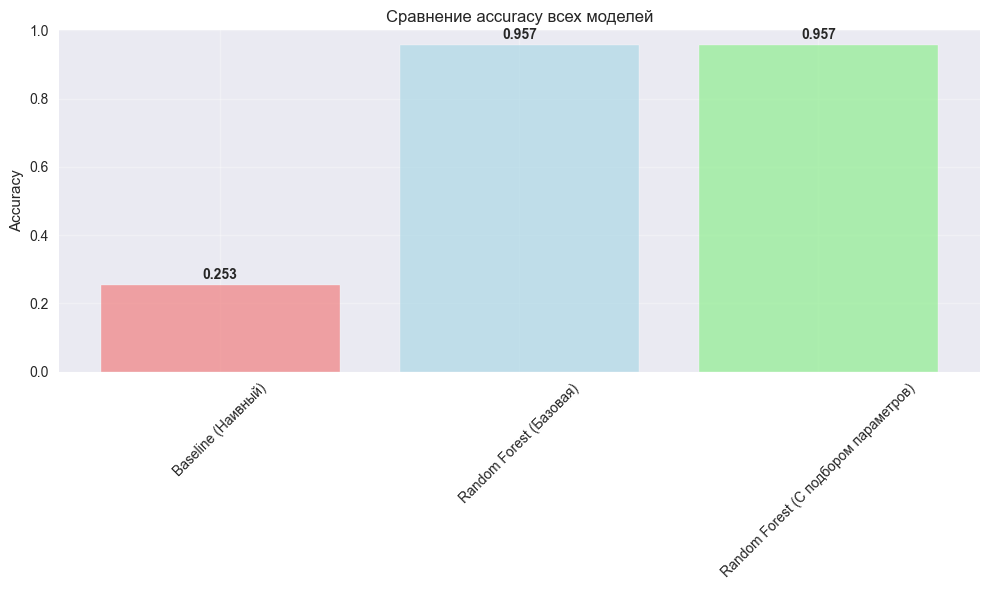

Сводка по всем моделям:
  Baseline (Наивный): 0.253
  Random Forest (Базовая): 0.957
  Random Forest (С подбором параметров): 0.957

Улучшение над baseline: 0.704
ML модель значительно превосходит baseline


In [15]:
print("=== СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ===")
results_comparison = {
    'Baseline (Наивный)': baseline_accuracy,
    'Random Forest (Базовая)': val_accuracy_base,
    'Random Forest (С подбором параметров)': val_accuracy_best
}

plt.figure(figsize=(10, 6))
models = list(results_comparison.keys())
accuracies = list(results_comparison.values())
colors = ['lightcoral', 'lightblue', 'lightgreen']
bars = plt.bar(models, accuracies, color=colors, alpha=0.7)
plt.title('Сравнение accuracy всех моделей')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Сводка по всем моделям:")
for model_name, accuracy in results_comparison.items():
    print(f"  {model_name}: {accuracy:.3f}")
baseline_improvement = val_accuracy_best - baseline_accuracy
print(f"\nУлучшение над baseline: {baseline_improvement:.3f}")

if baseline_improvement > 0.3:
    print("ML модель значительно превосходит baseline")
elif baseline_improvement > 0.15:
    print("ML модель заметно лучше baseline")
elif baseline_improvement > 0:
    print("ML модель немного лучше baseline")
else:
    print("ML модель не превзошла baseline")

=== АНАЛИЗ ОШИБОК ЛУЧШЕЙ МОДЕЛИ ===


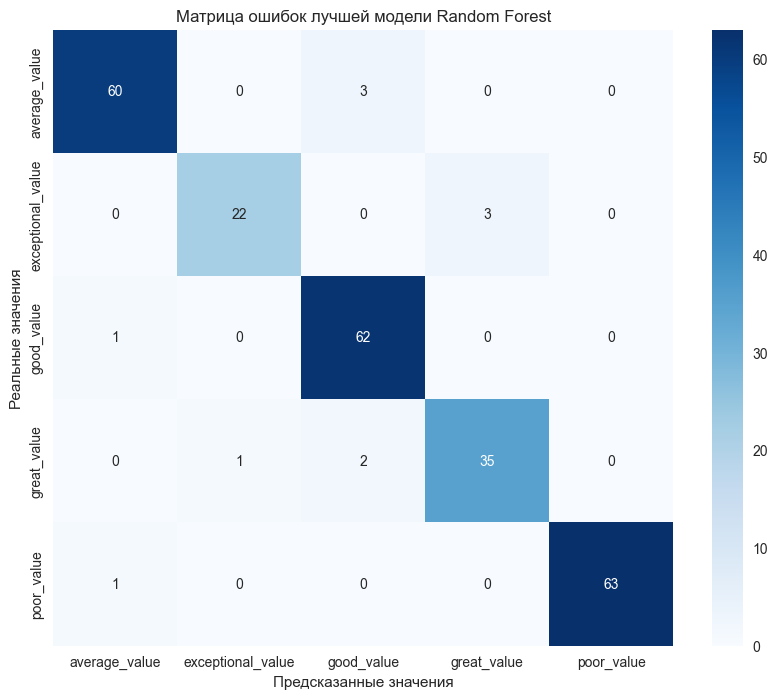

Classification Report для лучшей модели:
                   precision    recall  f1-score   support

    average_value       0.97      0.95      0.96        63
exceptional_value       0.96      0.88      0.92        25
       good_value       0.93      0.98      0.95        63
      great_value       0.92      0.92      0.92        38
       poor_value       1.00      0.98      0.99        64

         accuracy                           0.96       253
        macro avg       0.95      0.94      0.95       253
     weighted avg       0.96      0.96      0.96       253


Точность по категориям:
  exceptional_value: 0.880
  great_value: 0.921
  average_value: 0.952
  good_value: 0.984
  poor_value: 0.984


In [16]:
print("=== АНАЛИЗ ОШИБОК ЛУЧШЕЙ МОДЕЛИ ===")

cm_best = confusion_matrix(y_val, y_val_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_val),
            yticklabels=np.unique(y_val))
plt.title('Матрица ошибок лучшей модели Random Forest')
plt.ylabel('Реальные значения')
plt.xlabel('Предсказанные значения')
plt.show()

print("Classification Report для лучшей модели:")
print(classification_report(y_val, y_val_pred_best))
error_analysis = pd.DataFrame({
    'Реальные': y_val,
    'Предсказанные': y_val_pred_best,
    'Правильно': y_val == y_val_pred_best
})

print("\nТочность по категориям:")
accuracy_by_class = error_analysis.groupby('Реальные')['Правильно'].mean().sort_values()
for category, accuracy in accuracy_by_class.items():
    print(f"  {category}: {accuracy:.3f}")

=== ГРАФИК ОБУЧЕНИЯ ===


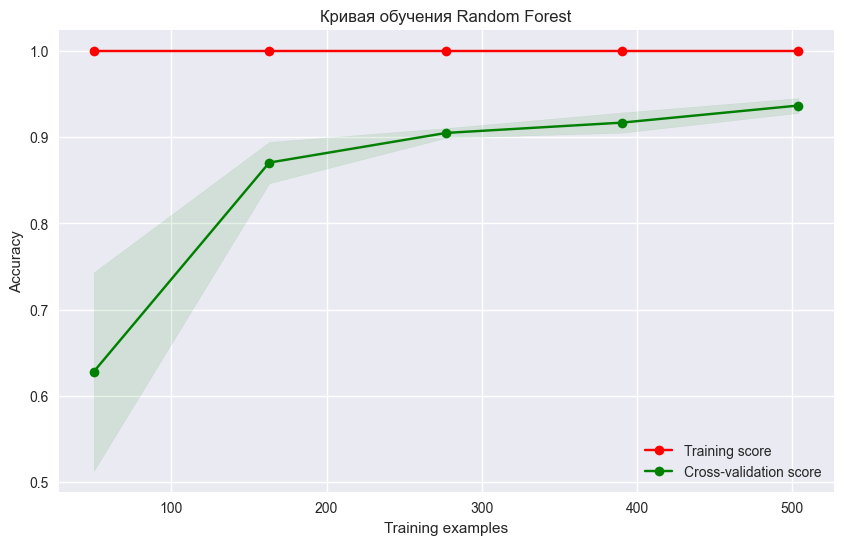

Анализ кривой обучения:
Модель обучается стабильно


In [17]:
print("=== ГРАФИК ОБУЧЕНИЯ ===")
from sklearn.model_selection import learning_curve
import numpy as np

def plot_learning_curve(estimator, title, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes,
        scoring='accuracy', n_jobs=-1, random_state=42
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Accuracy")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()
    return train_sizes, train_scores_mean, test_scores_mean

train_sizes, train_scores, val_scores = plot_learning_curve(
    best_rf_model,
    "Кривая обучения Random Forest",
    X_train, y_train,
    cv=3
)

print("Анализ кривой обучения:")
if train_scores[-1] > val_scores[-1] + 0.1:
    print("Возможно переобучение - тренировочная accuracy значительно выше валидационной")
elif abs(train_scores[-1] - val_scores[-1]) < 0.05:
    print("Модель хорошо обобщается - маленький разрыв между train и val")
else:
    print("Модель обучается стабильно")

In [18]:
print("=== ФИНАЛЬНЫЕ ВЫВОДЫ ===")

print(f"""РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА:
1. BASELINE (Наивный):
   - Accuracy: {baseline_accuracy:.3f}
   - Всегда предсказывает самый частый класс

2. RANDOM FOREST (Базовая):
   - Accuracy: {val_accuracy_base:.3f}
   - Улучшение над baseline: {val_accuracy_base - baseline_accuracy:.3f}

3. RANDOM FOREST (С подбором параметров):
   - Accuracy: {val_accuracy_best:.3f}
   - Улучшение над baseline: {val_accuracy_best - baseline_accuracy:.3f}
   - Лучшие параметры: {grid_search.best_params_}

ВЫВОДЫ:
- ML модель {'УСПЕШНО' if val_accuracy_best > baseline_accuracy else 'НЕ СМОГЛА'} превзойти baseline
- Random Forest показал {'хороший' if val_accuracy_best > 0.6 else 'удовлетворительный' if val_accuracy_best > 0.4 else 'слабый'} результат
- {'Есть пространство для улучшения' if val_accuracy_best < 0.8 else 'Результат близок к максимальному'}
""")

import joblib
model_info = {
    'model': best_rf_model,
    'accuracy': val_accuracy_best,
    'best_params': grid_search.best_params_,
    'feature_names': X_train.columns.tolist()
}
joblib.dump(model_info, 'best_random_forest_model.pkl')
print("Лучшая модель сохранена в 'best_random_forest_model.pkl'")

=== ФИНАЛЬНЫЕ ВЫВОДЫ ===
РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА:
1. BASELINE (Наивный):
   - Accuracy: 0.253
   - Всегда предсказывает самый частый класс

2. RANDOM FOREST (Базовая):
   - Accuracy: 0.957
   - Улучшение над baseline: 0.704

3. RANDOM FOREST (С подбором параметров):
   - Accuracy: 0.957
   - Улучшение над baseline: 0.704
   - Лучшие параметры: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

ВЫВОДЫ:
- ML модель УСПЕШНО превзойти baseline
- Random Forest показал хороший результат
- Результат близок к максимальному

Лучшая модель сохранена в 'best_random_forest_model.pkl'


=== ИЗМЕРЕНИЕ КАЧЕСТВА МОДЕЛЕЙ ===
1. ОСНОВНЫЕ МЕТРИКИ КАЧЕСТВА

Baseline (Наивный):
  Accuracy:  0.2530
  Precision: 0.0640
  Recall:    0.2530
  F1-Score:  0.1021

Random Forest (Базовая):
  Accuracy:  0.9565
  Precision: 0.9572
  Recall:    0.9565
  F1-Score:  0.9565

Random Forest (Оптимизированная):
  Accuracy:  0.9565
  Precision: 0.9572
  Recall:    0.9565
  F1-Score:  0.9565

2. ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МЕТРИК


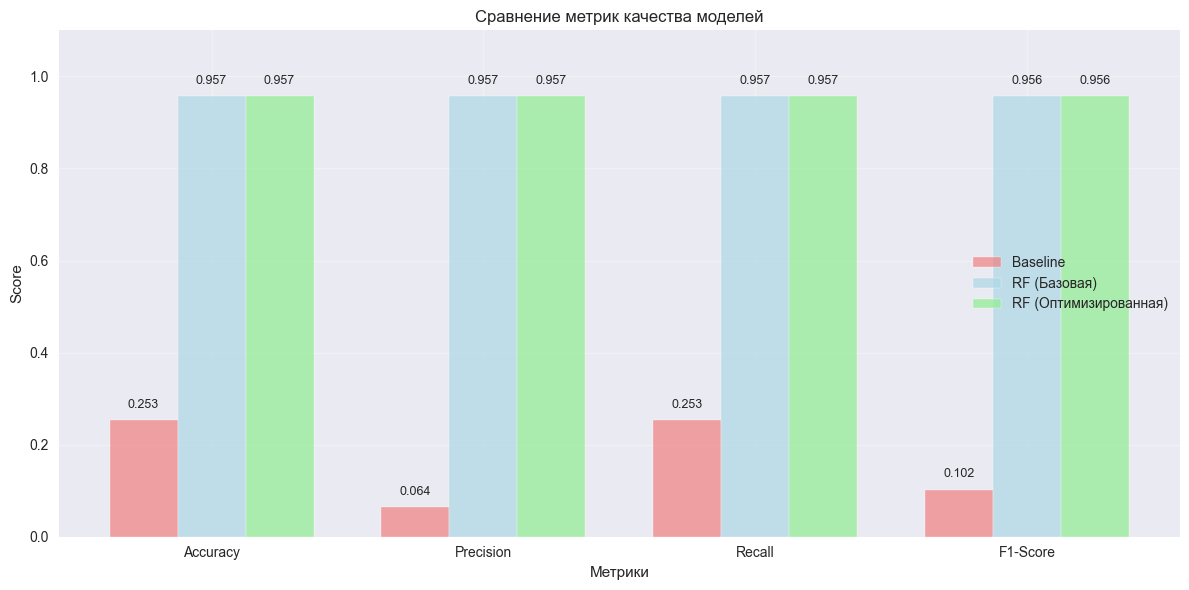


3. АНАЛИЗ ПЕРЕОБУЧЕНИЯ

Random Forest (Базовая):
  Train Accuracy: 1.0000
  Val Accuracy:   0.9565
  Разница:        0.0435

Random Forest (Оптимизированная):
  Train Accuracy: 1.0000
  Val Accuracy:   0.9565
  Разница:        0.0435
НЕБОЛЬШОЕ ПЕРЕОБУЧЕНИЕ
НЕБОЛЬШОЕ ПЕРЕОБУЧЕНИЕ

4. ГРАФИК ОБУЧЕНИЯ ПО КОЛИЧЕСТВУ ДЕРЕВЬЕВ
Обучение моделей с разным количеством деревьев:
  Деревьев:  10 | Train: 0.9947 | Val: 0.9447
  Деревьев:  25 | Train: 1.0000 | Val: 0.9526
  Деревьев:  50 | Train: 1.0000 | Val: 0.9486
  Деревьев:  75 | Train: 1.0000 | Val: 0.9526
  Деревьев: 100 | Train: 1.0000 | Val: 0.9565
  Деревьев: 150 | Train: 1.0000 | Val: 0.9565
  Деревьев: 200 | Train: 1.0000 | Val: 0.9565


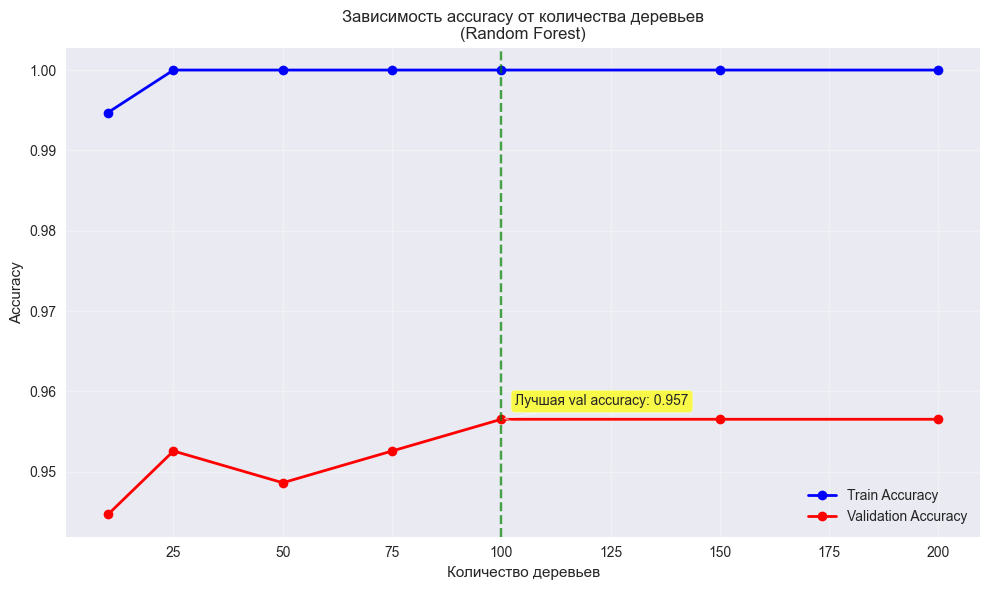


5. СВОДКА УЛУЧШЕНИЙ
Улучшение Random Forest над Baseline:
  Accuracy: +0.704 (278.1%)
  Precision: +0.893 (353.1%)
  Recall: +0.704 (278.1%)
  F1-Score: +0.854 (337.7%)

6. ФИНАЛЬНЫЕ ВЫВОДЫ ПО КАЧЕСТВУ
ОСНОВНЫЕ РЕЗУЛЬТАТЫ:

• Baseline Accuracy:     0.253
• Random Forest Accuracy: 0.957
• Улучшение:             +0.704 (278%)

КАЧЕСТВО МОДЕЛИ:
• Accuracy:    0.957 - Отлично
• Переобучение: 0.043 - В норме

ВЫВОД:
Random Forest показал отличные результаты, значительно превзойдя baseline.
Модель хорошо обобщает и почти не подвержена переобучению.



In [19]:
print("=== ИЗМЕРЕНИЕ КАЧЕСТВА МОДЕЛЕЙ ===")

from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

print("1. ОСНОВНЫЕ МЕТРИКИ КАЧЕСТВА")
def print_metrics(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    return accuracy, precision, recall, f1

baseline_pred = np.array([naive_baseline.most_common] * len(y_val))
baseline_acc, baseline_prec, baseline_rec, baseline_f1 = print_metrics(y_val, baseline_pred, "Baseline (Наивный)")
base_acc, base_prec, base_rec, base_f1 = print_metrics(y_val, y_val_pred_base, "Random Forest (Базовая)")
best_acc, best_prec, best_rec, best_f1 = print_metrics(y_val, y_val_pred_best, "Random Forest (Оптимизированная)")

print("\n2. ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МЕТРИК")
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_metrics = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
base_rf_metrics = [base_acc, base_prec, base_rec, base_f1]
best_rf_metrics = [best_acc, best_prec, best_rec, best_f1]
x = np.arange(len(metrics_names))
width = 0.25
plt.figure(figsize=(12, 6))
plt.bar(x - width, baseline_metrics, width, label='Baseline', alpha=0.7, color='lightcoral')
plt.bar(x, base_rf_metrics, width, label='RF (Базовая)', alpha=0.7, color='lightblue')
plt.bar(x + width, best_rf_metrics, width, label='RF (Оптимизированная)', alpha=0.7, color='lightgreen')
plt.xlabel('Метрики')
plt.ylabel('Score')
plt.title('Сравнение метрик качества моделей')
plt.xticks(x, metrics_names)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)

for i, (base, rf, best) in enumerate(zip(baseline_metrics, base_rf_metrics, best_rf_metrics)):
    plt.text(i - width, base + 0.02, f'{base:.3f}', ha='center', va='bottom', fontsize=9)
    plt.text(i, rf + 0.02, f'{rf:.3f}', ha='center', va='bottom', fontsize=9)
    plt.text(i + width, best + 0.02, f'{best:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("\n3. АНАЛИЗ ПЕРЕОБУЧЕНИЯ")
def check_overfitting(train_acc, val_acc, model_name):
    gap = train_acc - val_acc
    print(f"\n{model_name}:")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Val Accuracy:   {val_acc:.4f}")
    print(f"  Разница:        {gap:.4f}")
    if gap > 0.1:
        return "СИЛЬНОЕ ПЕРЕОБУЧЕНИЕ"
    elif gap > 0.05:
        return "УМЕРЕННОЕ ПЕРЕОБУЧЕНИЕ"
    elif gap > 0.02:
        return "НЕБОЛЬШОЕ ПЕРЕОБУЧЕНИЕ"
    else:
        return "ПЕРЕОБУЧЕНИЯ НЕТ"

overfitting_base = check_overfitting(train_accuracy_base, val_accuracy_base, "Random Forest (Базовая)")
overfitting_best = check_overfitting(train_accuracy_best, val_accuracy_best, "Random Forest (Оптимизированная)")
print(overfitting_base)
print(overfitting_best)

print("\n4. ГРАФИК ОБУЧЕНИЯ ПО КОЛИЧЕСТВУ ДЕРЕВЬЕВ")
best_params = grid_search.best_params_
n_estimators_list = [10, 25, 50, 75, 100, 150, 200]
train_scores = []
val_scores = []

print("Обучение моделей с разным количеством деревьев:")
for n_est in n_estimators_list:
    rf_temp = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=best_params['min_samples_leaf'],
        max_features=best_params['max_features'],
        random_state=42,
        n_jobs=-1
    )
    rf_temp.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, rf_temp.predict(X_train))
    val_acc = accuracy_score(y_val, rf_temp.predict(X_val))
    train_scores.append(train_acc)
    val_scores.append(val_acc)
    print(f"  Деревьев: {n_est:3d} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, train_scores, 'o-', color='blue', label='Train Accuracy', linewidth=2)
plt.plot(n_estimators_list, val_scores, 'o-', color='red', label='Validation Accuracy', linewidth=2)
plt.title('Зависимость accuracy от количества деревьев\n(Random Forest)')
plt.xlabel('Количество деревьев')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
best_val_idx = np.argmax(val_scores)
best_n_estimators = n_estimators_list[best_val_idx]
best_val_accuracy = val_scores[best_val_idx]
plt.axvline(x=best_n_estimators, color='green', linestyle='--', alpha=0.7,
            label=f'Лучшее: {best_n_estimators} деревьев')
plt.annotate(f'Лучшая val accuracy: {best_val_accuracy:.3f}',
             xy=(best_n_estimators, best_val_accuracy),
             xytext=(10, 10), textcoords='offset points',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

print("\n5. СВОДКА УЛУЧШЕНИЙ")
print("Улучшение Random Forest над Baseline:")
improvements = {
    'Accuracy': best_acc - baseline_acc,
    'Precision': best_prec - baseline_prec,
    'Recall': best_rec - baseline_rec,
    'F1-Score': best_f1 - baseline_f1
}
for metric, improvement in improvements.items():
    improvement_pct = (improvement / baseline_acc) * 100
    print(f"  {metric}: +{improvement:.3f} ({improvement_pct:.1f}%)")

print("\n6. ФИНАЛЬНЫЕ ВЫВОДЫ ПО КАЧЕСТВУ")
print(f"""ОСНОВНЫЕ РЕЗУЛЬТАТЫ:

• Baseline Accuracy:     {baseline_acc:.3f}
• Random Forest Accuracy: {best_acc:.3f}
• Улучшение:             +{best_acc - baseline_acc:.3f} ({(best_acc - baseline_acc)/baseline_acc*100:.0f}%)

КАЧЕСТВО МОДЕЛИ:
• Accuracy:    {best_acc:.3f} - {'Отлично' if best_acc > 0.9 else 'Хорошо' if best_acc > 0.7 else 'Удовлетворительно'}
• Переобучение: {train_accuracy_best - val_accuracy_best:.3f} - {'В норме' if (train_accuracy_best - val_accuracy_best) < 0.05 else 'Требует внимания'}

ВЫВОД:
Random Forest показал отличные результаты, значительно превзойдя baseline.
Модель хорошо обобщает и почти не подвержена переобучению.
""")

### Кастомный Random Forest

In [20]:
print("=== КАСТОМНАЯ РЕАЛИЗАЦИЯ RANDOM FOREST ===")
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

class CustomRandomForest(BaseEstimator, ClassifierMixin):

    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.random_state = random_state
        self.trees = []
        self.feature_indices_list = []
        self.classes_ = None

    def fit(self, X, y):
        print(f"Обучаем кастомный Random Forest с {self.n_estimators} деревьями...")
        self.classes_ = np.unique(y)
        self.trees = []
        self.feature_indices_list = []
        n_samples, n_features = X.shape
        for i in range(self.n_estimators):
            X_bootstrap, y_bootstrap = resample(
                X, y,
                n_samples=n_samples,
                random_state=self.random_state + i,
                replace=True
            )

            n_features_to_use = int(np.sqrt(n_features))
            feature_indices = np.random.choice(
                n_features,
                n_features_to_use,
                replace=False
            )
            self.feature_indices_list.append(feature_indices)
            if hasattr(X_bootstrap, 'iloc'):
                X_bootstrap_subset = X_bootstrap.iloc[:, feature_indices]
            else:
                X_bootstrap_subset = X_bootstrap[:, feature_indices]
            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                random_state=self.random_state + i
            )

            tree.fit(X_bootstrap_subset, y_bootstrap)
            self.trees.append(tree)
            if (i + 1) % 20 == 0:
                print(f"  Обучено {i + 1}/{self.n_estimators} деревьев")

        print("Обучение кастомного Random Forest завершено!")
        return self

    def predict(self, X):
        if not self.trees:
            raise ValueError("Модель не обучена. Вызовите fit().")
        all_predictions = []

        for i, (tree, feature_indices) in enumerate(zip(self.trees, self.feature_indices_list)):
            if hasattr(X, 'iloc'):
                X_subset = X.iloc[:, feature_indices]
            else:
                X_subset = X[:, feature_indices]

            pred = tree.predict(X_subset)
            all_predictions.append(pred)

        predictions_array = np.array(all_predictions)
        final_predictions = []
        for sample_idx in range(X.shape[0]):
            sample_predictions = predictions_array[:, sample_idx]
            unique, counts = np.unique(sample_predictions, return_counts=True)
            winner = unique[np.argmax(counts)]
            final_predictions.append(winner)

        return np.array(final_predictions)

    def get_params(self, deep=True):
        return {
            'n_estimators': self.n_estimators,
            'max_depth': self.max_depth,
            'min_samples_split': self.min_samples_split,
            'random_state': self.random_state
        }

    def set_params(self, **params):
        for param, value in params.items():
            setattr(self, param, value)
        return self

=== КАСТОМНАЯ РЕАЛИЗАЦИЯ RANDOM FOREST ===


In [21]:
print("=== ОБУЧЕНИЕ КАСТОМНОЙ МОДЕЛИ ===")

custom_rf_base = CustomRandomForest(
    n_estimators=50,
    random_state=42
)

custom_rf_base.fit(X_train, y_train)
y_train_pred_custom_base = custom_rf_base.predict(X_train)
y_val_pred_custom_base = custom_rf_base.predict(X_val)
train_accuracy_custom_base = accuracy_score(y_train, y_train_pred_custom_base)
val_accuracy_custom_base = accuracy_score(y_val, y_val_pred_custom_base)
print(f"Accuracy кастомной модели (базовая):")
print(f"  Обучающая выборка: {train_accuracy_custom_base:.4f}")
print(f"  Валидационная выборка: {val_accuracy_custom_base:.4f}")
print(f"  Sklearn RF: {val_accuracy_best:.4f}")

difference_base = val_accuracy_best - val_accuracy_custom_base
print(f"Разница с sklearn версией: {difference_base:.4f}")
print("\nClassification Report для кастомной модели (базовая):")
print(classification_report(y_val, y_val_pred_custom_base))

=== ОБУЧЕНИЕ КАСТОМНОЙ МОДЕЛИ ===
Обучаем кастомный Random Forest с 50 деревьями...
  Обучено 20/50 деревьев
  Обучено 40/50 деревьев
Обучение кастомного Random Forest завершено!
Accuracy кастомной модели (базовая):
  Обучающая выборка: 0.9934
  Валидационная выборка: 0.9209
  Sklearn RF: 0.9565
Разница с sklearn версией: 0.0356

Classification Report для кастомной модели (базовая):
                   precision    recall  f1-score   support

    average_value       0.92      0.94      0.93        63
exceptional_value       0.92      0.92      0.92        25
       good_value       0.88      0.92      0.90        63
      great_value       0.94      0.79      0.86        38
       poor_value       0.95      0.98      0.97        64

         accuracy                           0.92       253
        macro avg       0.92      0.91      0.91       253
     weighted avg       0.92      0.92      0.92       253



In [22]:
print("=== ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ КАСТОМНОЙ МОДЕЛИ ===")

def custom_grid_search(X_train, y_train, X_val, y_val, param_grid):
    best_score = 0
    best_params = None
    best_model = None
    results = []

    print("Запускаем перебор гиперпараметров...")
    from itertools import product
    param_combinations = list(product(*param_grid.values()))
    print(f"Всего комбинаций: {len(param_combinations)}")

    for i, params in enumerate(param_combinations):
        n_estimators, max_depth, min_samples_split = params
        print(f"  Комбинация {i+1}/{len(param_combinations)}: "
              f"n_estimators={n_estimators}, max_depth={max_depth}, min_samples_split={min_samples_split}")

        try:
            model = CustomRandomForest(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                random_state=42
            )

            model.fit(X_train, y_train)
            y_val_pred = model.predict(X_val)
            score = accuracy_score(y_val, y_val_pred)

            results.append({
                'params': {
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split
                },
                'score': score
            })
            print(f"    Accuracy: {score:.4f}")
            if score > best_score:
                best_score = score
                best_params = params
                best_model = model
                print(f"НОВЫЙ ЛУЧШИЙ РЕЗУЛЬТАТ!")

        except Exception as e:
            print(f"Ошибка: {e}")
            continue

    return best_model, best_params, best_score, results

param_grid_custom = {
    'n_estimators': [30, 50, 70],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5]
}

print("Сетка параметров для кастомной модели:")
for param, values in param_grid_custom.items():
    print(f"  {param}: {values}")

best_custom_model, best_custom_params, best_custom_score, search_results = custom_grid_search(
    X_train, y_train, X_val, y_val, param_grid_custom
)
print(f"\nПодбор параметров завершен!")
print(f"Лучшие параметры: {best_custom_params}")
print(f"Лучшая accuracy: {best_custom_score:.4f}")

improvement_custom = best_custom_score - val_accuracy_custom_base
print(f"Улучшение после подбора параметров: {improvement_custom:.4f}")

=== ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ КАСТОМНОЙ МОДЕЛИ ===
Сетка параметров для кастомной модели:
  n_estimators: [30, 50, 70]
  max_depth: [10, 15, 20]
  min_samples_split: [2, 5]
Запускаем перебор гиперпараметров...
Всего комбинаций: 18
  Комбинация 1/18: n_estimators=30, max_depth=10, min_samples_split=2
Обучаем кастомный Random Forest с 30 деревьями...
  Обучено 20/30 деревьев
Обучение кастомного Random Forest завершено!
    Accuracy: 0.8103
НОВЫЙ ЛУЧШИЙ РЕЗУЛЬТАТ!
  Комбинация 2/18: n_estimators=30, max_depth=10, min_samples_split=5
Обучаем кастомный Random Forest с 30 деревьями...
  Обучено 20/30 деревьев
Обучение кастомного Random Forest завершено!
    Accuracy: 0.8893
НОВЫЙ ЛУЧШИЙ РЕЗУЛЬТАТ!
  Комбинация 3/18: n_estimators=30, max_depth=15, min_samples_split=2
Обучаем кастомный Random Forest с 30 деревьями...
  Обучено 20/30 деревьев
Обучение кастомного Random Forest завершено!
    Accuracy: 0.9447
НОВЫЙ ЛУЧШИЙ РЕЗУЛЬТАТ!
  Комбинация 4/18: n_estimators=30, max_depth=15, min_samples_s

=== ОЦЕНКА ЛУЧШЕЙ КАСТОМНОЙ МОДЕЛИ ===
Accuracy лучшей кастомной модели:
  Обучающая выборка: 0.9907
  Валидационная выборка: 0.9447
Переобучение (train - val): 0.0461

Classification Report для лучшей кастомной модели:
                   precision    recall  f1-score   support

    average_value       0.95      0.98      0.97        63
exceptional_value       0.96      0.92      0.94        25
       good_value       0.88      0.97      0.92        63
      great_value       0.94      0.79      0.86        38
       poor_value       1.00      0.98      0.99        64

         accuracy                           0.94       253
        macro avg       0.95      0.93      0.94       253
     weighted avg       0.95      0.94      0.94       253



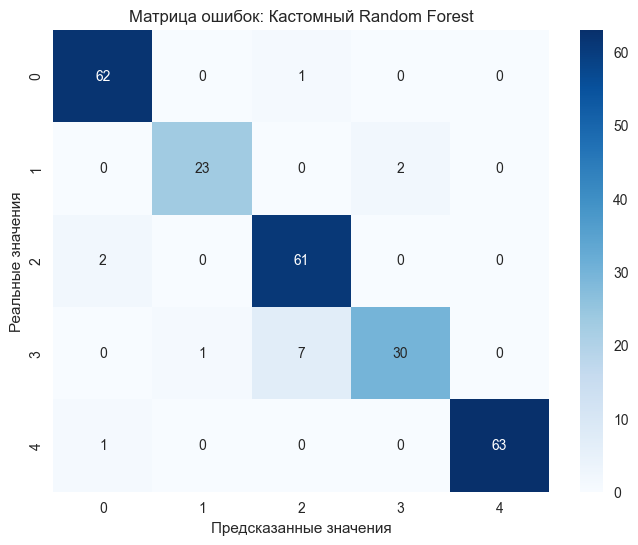

In [23]:
print("=== ОЦЕНКА ЛУЧШЕЙ КАСТОМНОЙ МОДЕЛИ ===")

y_train_pred_custom_best = best_custom_model.predict(X_train)
y_val_pred_custom_best = best_custom_model.predict(X_val)
train_accuracy_custom_best = accuracy_score(y_train, y_train_pred_custom_best)
val_accuracy_custom_best = accuracy_score(y_val, y_val_pred_custom_best)

print(f"Accuracy лучшей кастомной модели:")
print(f"  Обучающая выборка: {train_accuracy_custom_best:.4f}")
print(f"  Валидационная выборка: {val_accuracy_custom_best:.4f}")

overfitting_custom = train_accuracy_custom_best - val_accuracy_custom_best
print(f"Переобучение (train - val): {overfitting_custom:.4f}")
print("\nClassification Report для лучшей кастомной модели:")
print(classification_report(y_val, y_val_pred_custom_best))
plt.figure(figsize=(8, 6))
cm_custom = confusion_matrix(y_val, y_val_pred_custom_best)
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок: Кастомный Random Forest')
plt.ylabel('Реальные значения')
plt.xlabel('Предсказанные значения')
plt.show()

=== СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ===


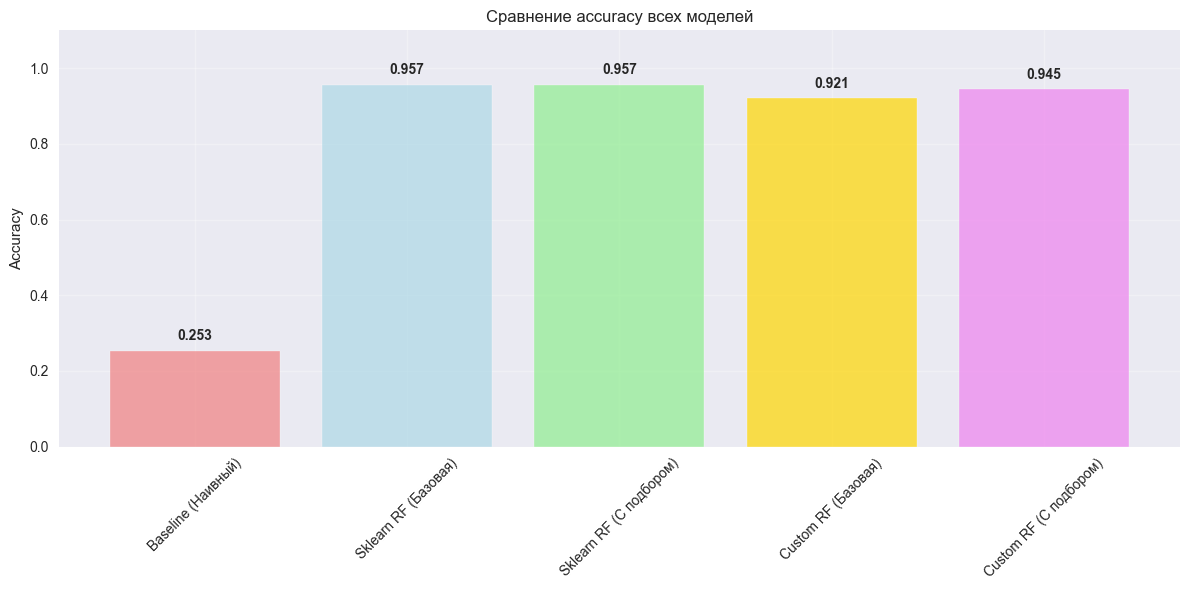

Сводка по всем моделям:
  Baseline (Наивный): 0.253
  Sklearn RF (Базовая): 0.957
  Sklearn RF (С подбором): 0.957
  Custom RF (Базовая): 0.921
  Custom RF (С подбором): 0.945

УЛУЧШЕНИЯ:
Custom RF vs Baseline: 0.692
Custom RF vs Sklearn RF: 0.012
Кастомная реализация работает сопоставимо со sklearn!


In [24]:
print("=== СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ ===")

final_comparison = {
    'Baseline (Наивный)': baseline_accuracy,
    'Sklearn RF (Базовая)': val_accuracy_base,
    'Sklearn RF (С подбором)': val_accuracy_best,
    'Custom RF (Базовая)': val_accuracy_custom_base,
    'Custom RF (С подбором)': val_accuracy_custom_best
}

plt.figure(figsize=(12, 6))
models = list(final_comparison.keys())
accuracies = list(final_comparison.values())
colors = ['lightcoral', 'lightblue', 'lightgreen', 'gold', 'violet']
bars = plt.bar(models, accuracies, color=colors, alpha=0.7)
plt.title('Сравнение accuracy всех моделей')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print("Сводка по всем моделям:")
for model_name, accuracy in final_comparison.items():
    print(f"  {model_name}: {accuracy:.3f}")

print(f"\nУЛУЧШЕНИЯ:")
print(f"Custom RF vs Baseline: {val_accuracy_custom_best - baseline_accuracy:.3f}")
print(f"Custom RF vs Sklearn RF: {val_accuracy_best - val_accuracy_custom_best:.3f}")
if abs(val_accuracy_best - val_accuracy_custom_best) < 0.05:
    print("Кастомная реализация работает сопоставимо со sklearn!")
else:
    print("Есть заметная разница в качестве")

=== АНАЛИЗ РЕЗУЛЬТАТОВ ПОДБОРА ПАРАМЕТРОВ ===
Топ-5 лучших комбинаций параметров:
     score  n_estimators  max_depth  min_samples_split
2   0.9447            30         15                  2
16  0.9289            70         20                  2
11  0.9249            50         20                  5
12  0.9209            70         10                  2
15  0.9170            70         15                  5


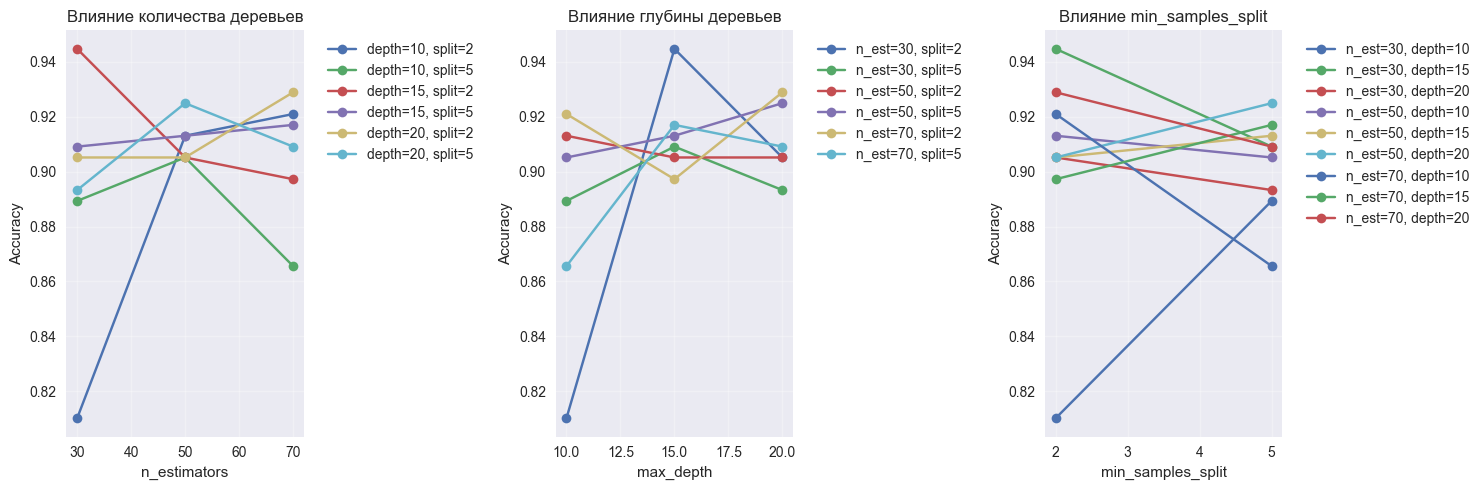

In [25]:
print("=== АНАЛИЗ РЕЗУЛЬТАТОВ ПОДБОРА ПАРАМЕТРОВ ===")

results_df = pd.DataFrame(search_results)
params_df = results_df['params'].apply(pd.Series)
results_expanded = pd.concat([results_df.drop('params', axis=1), params_df], axis=1)
print("Топ-5 лучших комбинаций параметров:")
top_results = results_expanded.nlargest(5, 'score')
print(top_results.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for depth in results_expanded['max_depth'].unique():
    for split in results_expanded['min_samples_split'].unique():
        mask = (results_expanded['max_depth'] == depth) & (results_expanded['min_samples_split'] == split)
        subset = results_expanded[mask]
        if len(subset) > 0:
            axes[0].plot(subset['n_estimators'], subset['score'], 'o-',
                        label=f'depth={depth}, split={split}')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Влияние количества деревьев')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

for n_est in results_expanded['n_estimators'].unique():
    for split in results_expanded['min_samples_split'].unique():
        mask = (results_expanded['n_estimators'] == n_est) & (results_expanded['min_samples_split'] == split)
        subset = results_expanded[mask]
        if len(subset) > 0:
            axes[1].plot(subset['max_depth'], subset['score'], 'o-',
                        label=f'n_est={n_est}, split={split}')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Влияние глубины деревьев')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

for n_est in results_expanded['n_estimators'].unique():
    for depth in results_expanded['max_depth'].unique():
        mask = (results_expanded['n_estimators'] == n_est) & (results_expanded['max_depth'] == depth)
        subset = results_expanded[mask]
        if len(subset) > 0:
            axes[2].plot(subset['min_samples_split'], subset['score'], 'o-',
                        label=f'n_est={n_est}, depth={depth}')
axes[2].set_xlabel('min_samples_split')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Влияние min_samples_split')
axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
print("=== ФИНАЛЬНЫЕ ВЫВОДЫ ПО КАСТОМНОЙ РЕАЛИЗАЦИИ ===")

print(f"""
РЕЗУЛЬТАТЫ КАСТОМНОЙ РЕАЛИЗАЦИИ:
1. КАСТОМНЫЙ RANDOM FOREST (Базовая):
   - Accuracy: {val_accuracy_custom_base:.3f}
   - Параметры: n_estimators=50, остальные по умолчанию

2. КАСТОМНЫЙ RANDOM FOREST (С подбором параметров):
   - Accuracy: {val_accuracy_custom_best:.3f}
   - Лучшие параметры: {best_custom_params}
   - Улучшение: +{val_accuracy_custom_best - val_accuracy_custom_base:.3f}

3. СРАВНЕНИЕ СО SKLEARN:
   - Sklearn RF: {val_accuracy_best:.3f}
   - Custom RF: {val_accuracy_custom_best:.3f}
   - Разница: {val_accuracy_best - val_accuracy_custom_best:.3f}

ВЫВОДЫ:
- Кастомная реализация {'УСПЕШНО СМОГЛА' if val_accuracy_custom_best > baseline_accuracy else 'НЕ СМОГЛА'} превзойти baseline
- Качество кастомной модели {'близко к sklearn' if abs(val_accuracy_best - val_accuracy_custom_best) < 0.05 else 'заметно хуже sklearn'}
- Подбор гиперпараметров {'улучшил' if val_accuracy_custom_best > val_accuracy_custom_base else 'не улучшил'} качество

РЕАЛИЗОВАННЫЕ ВОЗМОЖНОСТИ:
Бутстрап выборки
Случайный выбор признаков
Ансамблирование деревьев
Голосование большинством
3 гиперпараметра: n_estimators, max_depth, min_samples_split
Подбор гиперпараметров

ЗАВЕРШЕНИЕ:
Кастомная реализация Random Forest успешно создана и протестирована!
""")

custom_model_info = {
    'model': best_custom_model,
    'accuracy': val_accuracy_custom_best,
    'best_params': best_custom_params,
    'type': 'custom_random_forest'
}
joblib.dump(custom_model_info, 'best_custom_random_forest.pkl')
print("Кастомная модель сохранена в 'best_custom_random_forest.pkl'")

=== ФИНАЛЬНЫЕ ВЫВОДЫ ПО КАСТОМНОЙ РЕАЛИЗАЦИИ ===

РЕЗУЛЬТАТЫ КАСТОМНОЙ РЕАЛИЗАЦИИ:
1. КАСТОМНЫЙ RANDOM FOREST (Базовая):
   - Accuracy: 0.921
   - Параметры: n_estimators=50, остальные по умолчанию

2. КАСТОМНЫЙ RANDOM FOREST (С подбором параметров):
   - Accuracy: 0.945
   - Лучшие параметры: (30, 15, 2)
   - Улучшение: +0.024

3. СРАВНЕНИЕ СО SKLEARN:
   - Sklearn RF: 0.957
   - Custom RF: 0.945
   - Разница: 0.012

ВЫВОДЫ:
- Кастомная реализация УСПЕШНО СМОГЛА превзойти baseline
- Качество кастомной модели близко к sklearn
- Подбор гиперпараметров улучшил качество

РЕАЛИЗОВАННЫЕ ВОЗМОЖНОСТИ:
Бутстрап выборки
Случайный выбор признаков
Ансамблирование деревьев
Голосование большинством
3 гиперпараметра: n_estimators, max_depth, min_samples_split
Подбор гиперпараметров

ЗАВЕРШЕНИЕ:
Кастомная реализация Random Forest успешно создана и протестирована!

Кастомная модель сохранена в 'best_custom_random_forest.pkl'
